# 6 · Mounts, stiffness matrices and the elastic centre

**Math primer — notebook 6 of 7.**

Notebook 1 built a stiffness matrix from springs between scalar coordinates.
Now the springs sit at *positions* on a rigid body, and moving the body moves each
mount by an amount that depends on both translation and rotation.

**You should come out knowing:** how a single mount at $\{r\}$ contributes to the
$6\times6$ $[K]$, what the skew-symmetric matrix is doing there, what the elastic
centre is, and the geometric reason narrow lateral mount spacing collapses roll
stiffness without touching anything else.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import primer
from primer import SERIES, INK, INK2, GRID, tidy
primer.use_style()

## 6.1 · How far does a mount deflect?

Small rigid-body motion $\{q\}=[\{u\},\{\theta\}]$ moves the material point at
$\{r\}$ by

$$\{d\}=\{u\}+\{\theta\}\times\{r\}$$

Cross products are linear, so write them as a matrix. For any vector $\{v\}$
define the **skew-symmetric matrix**

$$[S(v)]=\begin{bmatrix}0&-v_z&v_y\\ v_z&0&-v_x\\ -v_y&v_x&0\end{bmatrix}
\qquad\text{so that}\qquad [S(v)]\{w\}=\{v\}\times\{w\}$$

Then $\{\theta\}\times\{r\}=-[S(r)]\{\theta\}$ and

$$\{d\}=\begin{bmatrix}[I_3] & -[S(r)]\end{bmatrix}\{q\}\;\equiv\;[B]\{q\}$$

In [2]:
def skew(v):
    x, y, z = v
    return np.array([[0.0, -z, y], [z, 0.0, -x], [-y, x, 0.0]])

r = np.array([0.23, 0.05, -0.12])
th = np.array([0.01, -0.02, 0.03])
print("theta x r  (numpy cross) :", np.cross(th, r))
print("S(theta) @ r             :", skew(th) @ r)
print("-S(r) @ theta            :", -skew(r) @ th)

def B_of(r):
    return np.hstack([np.eye(3), -skew(r)])

q = np.array([1e-3, 0, 0, 0.01, -0.02, 0.03])
print("\ndeflection of the mount at r for q =", q, ":\n ", B_of(r) @ q)

theta x r  (numpy cross) : [0.0009 0.0081 0.0051]
S(theta) @ r             : [0.0009 0.0081 0.0051]
-S(r) @ theta            : [0.0009 0.0081 0.0051]

deflection of the mount at r for q = [ 0.001  0.     0.     0.01  -0.02   0.03 ] :
  [0.0019 0.0081 0.0051]


## 6.2 · One mount's contribution to $[K]$

Same energy argument as notebook 1. The mount stores
$\tfrac12\{d\}^\mathsf{T}[k]\{d\}$ with $[k]$ its $3\times3$ rate matrix, so with
$\{d\}=[B]\{q\}$ the energy is $\tfrac12\{q\}^\mathsf{T}[B]^\mathsf{T}[k][B]\{q\}$
and

$$[K]_{\text{mount}}=[B]^\mathsf{T}[k][B]
=\begin{bmatrix}[k] & -[k][S(r)]\\ [S(r)][k] & -[S(r)][k][S(r)]\end{bmatrix}$$

Exactly the same pattern as $k\{b\}\{b\}^\mathsf{T}$ in notebook 1 — a congruence
transform of the mount's own rate matrix into the body's coordinates. Symmetry is
automatic, and so is positive semi-definiteness.

If the mount's own principal directions are not $x,y,z$ (a bush at an angle),
first rotate its rates: $[k]=[R_m]\,\mathrm{diag}(k_1,k_2,k_3)\,[R_m]^\mathsf{T}$.

In [3]:
def mount_K(r, rates, R_m=None):
    """6x6 stiffness contribution of one mount at position r."""
    R_m = np.eye(3) if R_m is None else R_m
    k = R_m @ np.diag(rates) @ R_m.T
    B = B_of(r)
    return B.T @ k @ B

Km = mount_K([0.23, 0.05, -0.12], [4.9e6, 1.1e6, 4.9e6])
ev = np.linalg.eigvalsh(Km)
print("symmetric?", np.allclose(Km, Km.T))
print("eigenvalues:", ev)
print(f"most negative eigenvalue: {ev.min():.2e}  "
      f"(zero to round-off, relative to {ev.max():.2e})")
print("rank:", np.linalg.matrix_rank(Km), " <- one mount restrains only 3 of 6 DOF")

symmetric? True
eigenvalues: [     -0.          -0.           0.     1173787.4223 4912492.5777 5242020.    ]
most negative eigenvalue: -2.13e-10  (zero to round-off, relative to 5.24e+06)
rank: 3  <- one mount restrains only 3 of 6 DOF


A single mount has rank 3 — it cannot stop the body rotating about itself. You
need enough mounts, well spread, for $[K]$ to become full rank. That is the
6-DOF version of "the structure must be properly restrained".

## 6.3 · Four mounts, and the block structure appearing

Put four bushes on symmetrically in $y$ and watch which entries survive.

K (units N/m and N m/rad mixed -- see note below):

                   x           y           z           φ           θ           ψ
     x      1.76e+07           0           0           0   -9.74e+04           0
     y             0     3.9e+06           0    2.86e+04           0     6.4e+04
     z             0           0    1.76e+07           0   -2.26e+05           0
     φ             0    2.86e+04           0    1.03e+05           0    1.17e+05
     θ     -9.74e+04           0   -2.26e+05           0    1.31e+06           0
     ψ             0     6.4e+04           0    1.17e+05           0    2.75e+05


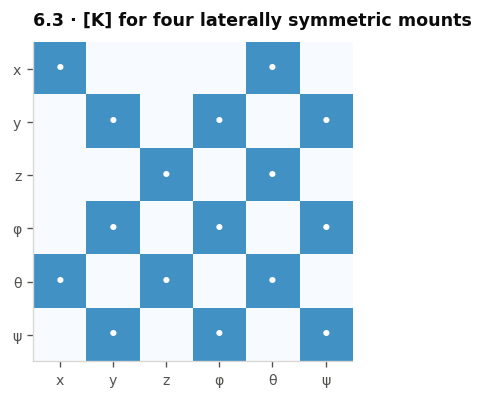

In [4]:
def four_mounts(x_f=0.23, x_r=-0.26, z_f=-0.115, z_r=0.132, y_half=0.05,
                kf=(4.9e6, 1.1e6, 4.9e6), kr=(3.9e6, 0.85e6, 3.9e6), tilt=0.0):
    c, s = np.cos(tilt), np.sin(tilt)
    R_m = np.array([[c, 0, s], [0, 1.0, 0], [-s, 0, c]])
    K = np.zeros((6, 6))
    for x, z, kk in ((x_f, z_f, kf), (x_r, z_r, kr)):
        for sy in (+1, -1):
            K += mount_K([x, sy*y_half, z], kk, R_m)
    return K

K6 = four_mounts()
lab = ["x", "y", "z", "φ", "θ", "ψ"]
np.set_printoptions(precision=1, suppress=True)
print("K (units N/m and N m/rad mixed -- see note below):\n")
print("        " + "".join(f"{l:>12s}" for l in lab))
for i, l in enumerate(lab):
    print(f"{l:>6s}  " + "".join(f"{v:12.3g}" for v in K6[i]))
np.set_printoptions(precision=4, suppress=True)

fig, ax = plt.subplots(figsize=(3.6, 3.4))
ax.imshow(np.abs(K6) > 1e-6 * np.abs(K6).max(), cmap="Blues", vmin=0, vmax=1.6)
for i in range(6):
    for j in range(6):
        if abs(K6[i, j]) > 1e-6 * np.abs(K6).max():
            ax.text(j, i, "•", ha="center", va="center", color="white", fontsize=13)
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels(lab); ax.set_yticklabels(lab); ax.grid(False)
tidy(ax, "6.3 · [K] for four laterally symmetric mounts")
plt.tight_layout(); plt.show()

Lateral symmetry kills every entry that would couple the in-plane motions
($x,z,\theta$) to the out-of-plane ones ($y,\phi,\psi$). What survives is the
$x$–$z$–$\theta$ block and the $y$–$\phi$–$\psi$ block. Combine that with the
inertia structure from notebook 5 and you get the paper's Eq. (7) picture.

> **A note on units.** Mixing translations (m) and rotations (rad) in one vector
> means $[K]$ has mixed units: N/m, N/rad, N·m/rad. That is harmless for the
> algebra but makes the printed numbers hard to compare, and it means "the
> largest entry of a mode shape" is not a meaningful notion until you scale
> rotations by a characteristic length. `orthomount.describe_mode` does exactly
> that, with a 0.25 m default.

## 6.4 · The elastic centre

The translation–rotation coupling block is $-[k][S(r)]$ summed over mounts. There
is generally one point — the **elastic centre** — about which that block
vanishes: push there and the body translates without rotating.

Shift the origin by $\{r_e\}$ and the coupling block becomes
$[K_c]+[K_t][S(r_e)]$. Setting it to zero and solving column by column locates it.

In [5]:
def elastic_centre(K):
    Kt, Kc = K[:3, :3], K[:3, 3:]
    A = np.zeros((9, 3)); b = np.zeros(9)
    for i in range(3):
        e = np.zeros(3); e[i] = 1.0
        A[3*i:3*i+3, :] = Kt @ skew(e)
        b[3*i:3*i+3] = Kc[:, i]
    return np.linalg.lstsq(A, b, rcond=None)[0]

print("elastic centre of the four-mount set:", elastic_centre(four_mounts()) * 1000, "mm")

# deliberately move the front mounts up and watch it shift
print("front mounts 60 mm higher   :",
      elastic_centre(four_mounts(z_f=-0.055)) * 1000, "mm")
print("front mounts twice as stiff :",
      elastic_centre(four_mounts(kf=(9.8e6, 2.2e6, 9.8e6))) * 1000, "mm")

elastic centre of the four-mount set: [13.008   0.     -5.6183] mm
front mounts 60 mm higher   : [13.008   0.     27.8112] mm
front mounts twice as stiff : [ 90.6494   0.     -44.7559] mm


The paper *assumes* the elastic centre coincides with the CG. That is what makes
its $[K]$ block-diagonal and lets the 6-DOF problem collapse to $2\times2$. In a
real layout it is a design target you have to hit, not a given — which is why
`orthomount`'s mount-layout solver carries it as an explicit residual.

## 6.5 · The lever arms — why narrow spacing collapses roll stiffness

Multiply out $[B]^\mathsf{T}[k][B]$ for a mount with rates $(k_x,k_y,k_z)$ at
$(x,y,z)$ and read the rotational diagonal:

$$K_{\phi\phi}=k_z y^2 + k_y z^2,\qquad
  K_{\theta\theta}=k_z x^2 + k_x z^2,\qquad
  K_{\psi\psi}=k_y x^2 + k_x y^2$$

Roll stiffness is the only one carrying $y^2$ against the big vertical rate.
Squeeze the mounts together laterally and $K_{\phi\phi}$ falls as $y^2$ while
bounce, fore/aft and pitch do not move at all.

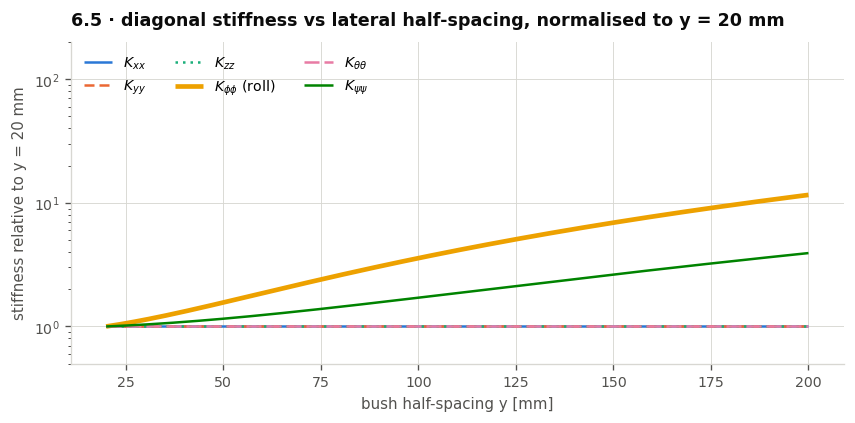

Only roll and yaw depend on lateral spacing; roll is the one that matters,
because it is the direction the engine's rocking couple pushes in.


In [6]:
ys = np.linspace(0.02, 0.20, 200)
diag = np.array([np.diag(four_mounts(y_half=yy)) for yy in ys])

fig, ax = plt.subplots(figsize=(7.2, 3.6))
names = ["$K_{xx}$", "$K_{yy}$", "$K_{zz}$",
         r"$K_{\phi\phi}$ (roll)", r"$K_{\theta\theta}$", r"$K_{\psi\psi}$"]
# The four spacing-independent curves sit exactly on top of each other at 1.0,
# so give them distinct dashes -- otherwise only the last one drawn is visible.
dashes = [(1, 0), (4, 2), (1, 2), (1, 0), (6, 2), (1, 0)]
for j in range(6):
    lw = 2.8 if j == 3 else 1.5
    ax.semilogy(ys*1000, diag[:, j]/diag[0, j], color=SERIES[j], lw=lw,
                dashes=dashes[j], label=names[j])
ax.set_ylim(0.5, 200)
tidy(ax, "6.5 · diagonal stiffness vs lateral half-spacing, normalised to y = 20 mm",
     "bush half-spacing y [mm]", "stiffness relative to y = 20 mm")
ax.legend(ncol=3, loc="upper left")
plt.tight_layout(); plt.show()

print("Only roll and yaw depend on lateral spacing; roll is the one that matters,")
print("because it is the direction the engine's rocking couple pushes in.")

### Cross-check against the library

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import orthomount as om

mounts = []
for x, z, kk in ((0.23, -0.115, (4.9e6, 1.1e6, 4.9e6)),
                 (-0.26, 0.132, (3.9e6, 0.85e6, 3.9e6))):
    for sy in (+1, -1):
        mounts.append(om.Mount([x, sy*0.05, z], kk))
body = om.RigidBody.from_principal(40.0, 0.95, 1.30, 1.60, np.deg2rad(30))
K_lib = om.MountSystem(body, mounts).K

print("hand-built matches orthomount?", np.allclose(K_lib, four_mounts()))
print("max difference:", np.max(np.abs(K_lib - four_mounts())))

hand-built matches orthomount? True
max difference: 0.0


---

**Next:** [7 · Putting it together — the paper's 2×2](07_the_papers_2x2.ipynb)